# Filtering TM/TR CDF plot (0603)

Set `DATA_FOLDER`, then run all cells. This notebook only draws the original CDF data up to `QUANTILE_DROP=0.995`; it does not drop data and does not renormalize the CDF.


In [49]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [50]:
# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260604/c920bn3/output_filt/20260604-103059/') #920bn3,dsub
DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260604/camd9554n2/output_filt/20260604-103123/') #amd9554n2,dsub
# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260604/cgnr6760pn2/output_filt/20260604-103109/') #gnr6760pn2,dsub

# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/output_tvkern_filt/20260601-215336/')

# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260603/cgnr6760pn2/output_filt/20260603-224125/')
# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-230850') # dsub
# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330') # ssub

# DATA_FOLDER = Path('/astrum/home/hpchzy/code/data/20260603/cgnr6760pn2/output_filt/20260603-232427') # ssub


HOSTNAME = DATA_FOLDER.parts[-3]
assert HOSTNAME in ['cgnr6760pn2', 'camd9554n2', 'c920bn3'], f'Unexpected hostname {HOSTNAME} in DATA_FOLDER path'

QUANTILE_DROP = 0.995  # only draw CDF values from 0 to 0.995; no data deletion, no renormalization
SAVE_FIG = False
OUT_DIR = DATA_FOLDER / 'plots_0603'

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#00a6d6',
    'cntvcto': '#e377c2',
}


In [51]:
def parse_filt_dir(path):
    m = re.match(r'(?P<kernel>.+)_(?P<timer>.+)_np(?P<np>\d+)_size(?P<size>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    return d


def timer_label(timer):
    return timer.upper().replace('_', '-')


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid', 'cntvct', 'cntvcto']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    return vals[keep], y[keep]


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    df['cdf'] = df['prob'].cumsum()
    if len(df) and df['cdf'].iloc[-1] != 0:
        df['cdf'] = df['cdf'] / df['cdf'].iloc[-1]
    return df[df['cdf'] <= QUANTILE_DROP]


def collect_entries(data_folder):
    rows = []
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = collect_entries(DATA_FOLDER)
print(f'entries: {len(entries)}')
entries.sort_values(['kernel', 'np', 'size', 'timer']).head(20)




entries: 42


,kernel,timer,np,size,filt_dir,tm_file,tr_hist_file
5,jacobi2d5p,cgt,64,64,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
11,jacobi2d5p,likwid,64,64,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
17,jacobi2d5p,papi,64,64,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
23,jacobi2d5p,papix6,64,64,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
35,jacobi2d5p,tsc,64,64,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
41,jacobi2d5p,wtime,64,64,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
1,jacobi2d5p,cgt,64,128,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
7,jacobi2d5p,likwid,64,128,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
13,jacobi2d5p,papi,64,128,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...
19,jacobi2d5p,papix6,64,128,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...,/astrum/home/hpchzy/code/data/20260604/camd955...


# ER/EP/Wasserstein

In [52]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])

    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')

    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")

    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['kernel', 'np', 'size', 'timer'], inplace=True)
df[['kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)


,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
5,jacobi2d5p,cgt,64,64,0.000000,0.270793,19.734673,0.000000,0.000000
11,jacobi2d5p,likwid,64,64,0.125200,0.328077,42.112563,54.950756,1.431160
17,jacobi2d5p,papi,64,64,0.000735,0.036699,20.122613,14.680876,14.680880
23,jacobi2d5p,papix6,64,64,0.000304,0.029186,16.175879,13.464240,13.464240
35,jacobi2d5p,tsc,64,64,0.191636,0.242876,15.024121,0.000000,0.000000
41,jacobi2d5p,wtime,64,64,0.003597,0.357518,27.742714,7.492059,7.492060
1,jacobi2d5p,cgt,64,128,0.000000,0.144340,16.732663,0.000000,0.000000
7,jacobi2d5p,likwid,64,128,0.210653,0.283336,66.730653,125.340266,44.225434
13,jacobi2d5p,papi,64,128,0.002443,0.020135,11.858291,15.527353,15.527360
19,jacobi2d5p,papix6,64,128,0.004001,0.027934,16.602010,13.430526,13.430520


In [53]:
TIMER_LABELS = {
    "tsc": "TSC",
    "tsc_fence": "TSC_Fence",
    "tsc_native": "TSC_Native",
    "cgt": "clock_gettime",
    "wtime": "MPI_Wtime",
    "papi": "PAPI",
    "papix6": "PAPIx6",
    "likwid": "LIKWID",
    "cntvct": "CNTVCT",
    "cntvcto": "CNTVCTO",
}

KERNEL_LABELS = {
    "jacobi2d5p": "2D 5-Point Jacobi Stencil"
}

HOST_LABELS = {
    "c920bn3": "Kunpeng 920B",
    "camd9554n2": "AMD EPYC 9554",
    "cgnr6760pn2": "Intel Xeon 6760P"
}

df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

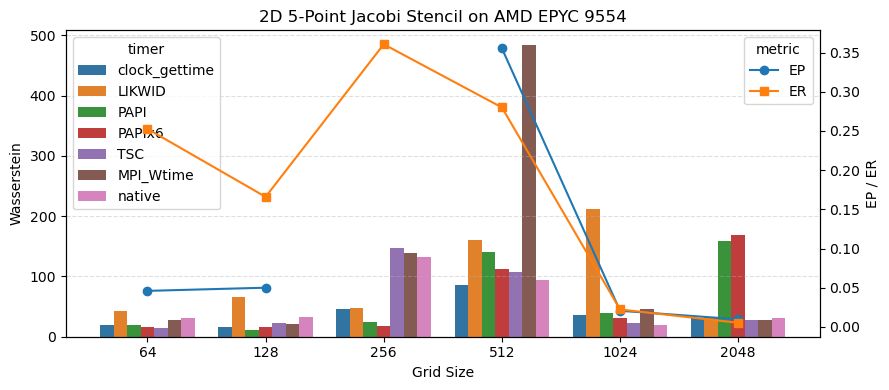

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metric_bar = "wd"
line_metrics = ["ep", "er"]

plot_df = df.copy()

# size 转成分类字符串，保证横轴等间距
size_order = [str(x) for x in sorted(plot_df["size"].unique())]
plot_df["size_str"] = plot_df["size"].astype(str)
plot_df["size_str"] = pd.Categorical(
    plot_df["size_str"],
    categories=size_order,
    ordered=True
)

fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.set_title(f"{KERNEL_LABELS.get(plot_df['kernel'].iloc[0], plot_df['kernel'].iloc[0])} on {HOST_LABELS.get(HOSTNAME, HOSTNAME)}")

# 左轴：wd 多柱状图
sns.barplot(
    data=plot_df,
    x="size_str",
    y=metric_bar,
    hue="timer_label",
    ax=ax1
)

ax1.set_xlabel("Grid Size")
ax1.set_ylabel("Wasserstein")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# 右轴：ep / er 折线图
ax2 = ax1.twinx()

# 如果每个 size/timer 有多行，先聚合
line_df = (
    plot_df
    .groupby(["size_str"], observed=True)[line_metrics]
    .mean()
    .reset_index()
)

x_pos = range(len(line_df))

ax2.plot(
    x_pos,
    line_df["ep"],
    marker="o",
    label="EP"
)

ax2.plot(
    x_pos,
    line_df["er"],
    marker="s",
    label="ER"
)

ax2.set_ylabel("EP / ER")

# 因为 ax2 用的是数值坐标，需要和 ax1 的 categorical x 对齐
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(line_df["size_str"])

# 合并两个 legend
handles1, labels1 = ax1.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    title="timer",
    loc="upper left"
)
ax2.legend(
    title="metric",
    loc="upper right"
)

plt.tight_layout()
plt.show()

# Filt Plot

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

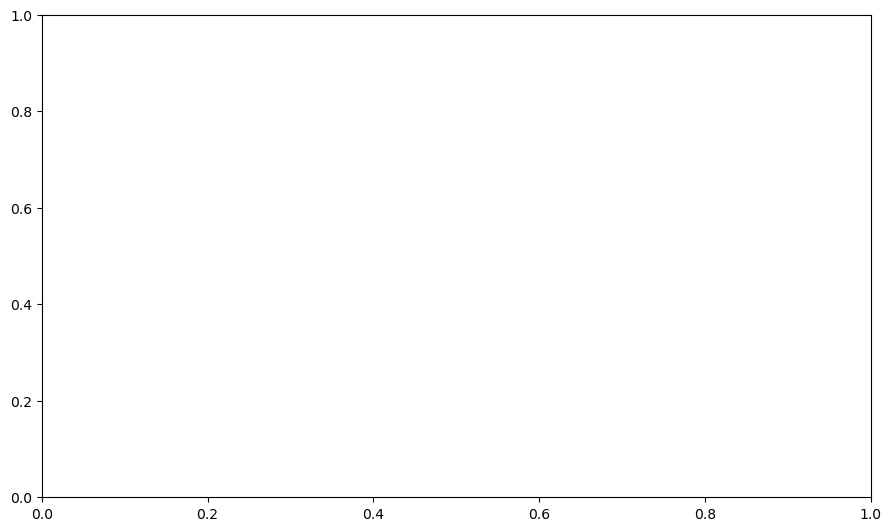

In [55]:
entries_plot = entries[entries['size'] == 256]


if entries_plot.empty:
    raise RuntimeError(f'No *_filt/tr_hist.csv entries found under {DATA_FOLDER}')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

for (kernel, np_val, size), group in entries_plot.groupby(['kernel', 'np', 'size'], sort=True):
    fig, ax = plt.subplots(figsize=(8.8, 5.2), constrained_layout=True)
    group = group.sort_values('timer', key=lambda s: s.map(timer_sort_key))

    for _, row in group.iterrows():
        timer = row['timer']
        color = TIMER_COLORS.get(timer)
        label = timer_label(timer)

        tm_x, tm_y = ecdf_xy(read_tm(row['tm_file']))
        tr_df = read_tr(row['tr_hist_file'])

        ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.7)
        ax.step(tr_df['ns'], tr_df['cdf'], label=f'{label}-TR', color=color, linestyle='-', linewidth=1.7, where='post')

    ax.set_title(f'{kernel}  np={np_val}  size={size}  CDF<=q{QUANTILE_DROP}')
    ax.set_xlabel('time (ns)')
    ax.set_ylabel('CDF')
    ax.set_ylim(0, QUANTILE_DROP)
    ax.grid(True, alpha=0.28)
    ax.legend(ncol=2, fontsize=9)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_np{np_val}_size{size}_tm_tr_all_timers.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()